# Check single source in DP1 for DCR

Author: Maya Redden, msredden@stanford.edu

In [9]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import synth_fnu


In [10]:
# If data is downloaded from the RSP...

'''
# Load DP1 data
# Need a .vot table of source catalog entries of all visits of a single object
# Need a .vot table of all visits in the survey that overlap with the object


source_file = 'DP1_tests/dp1_test9_source.vot'
source_table = parse(source_file)
source_table = source_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
source_default_column_names = ['col_0', 'col', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col0', 'col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7']
source_column_names = ['band','calibFlux','calibFluxErr','coord_dec','coord_ra','dec','decErr','ixx','ixxPSF','ixy','ixyPSF','iyy','iyyPSF','psfFlux','psfFluxErr','ra','raErr','visit']

for i, col in enumerate(source_default_column_names):
    source_table.rename_column(col, source_column_names[i])



visit_file = 'DP1_tests/dp1_ecdfs_allvisits.vot'
visit_table = parse(visit_file)
visit_table = visit_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
visit_default_column_names = ['col_0', 'col', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col0']
visit_column_names = ['airmass','altitude','azimuth','band','dec','expTime','ra','skyRotation','visit','zenithDistance','expMidptMJD']

for i, col in enumerate(visit_default_column_names):
    visit_table.rename_column(col, visit_column_names[i])

'''



"\n# Load DP1 data\n# Need a .vot table of source catalog entries of all visits of a single object\n# Need a .vot table of all visits in the survey that overlap with the object\n\n\nsource_file = 'DP1_tests/dp1_test9_source.vot'\nsource_table = parse(source_file)\nsource_table = source_table.get_first_table().to_table()\n\n#rename columns to something more descriptive (data must have been downloaded with these columns selected)\nsource_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17']\nsource_column_names = ['band','calibFlux','calibFluxErr','coord_dec','coord_ra','dec','decErr','ixx','ixxPSF','ixy','ixyPSF','iyy','iyyPSF','psfFlux','psfFluxErr','ra','raErr','visit']\n\nfor i, col in enumerate(source_default_column_names):\n    source_table.rename_column(col, source_column_names[i])\n\n\n\nvisit_file = 'DP1_tests/dp1_ecdfs_allvisits.vot'\nvisit

In [11]:
# Getting data using the tap service:

try:
    #if on the RSP...
    from lsst.rsp import get_tap_service
    service = get_tap_service("tap")
    
    def queryTAP(query):
        job = service.submit_job(query)
        job.run()
        job.wait(phases=['COMPLETED', 'ERROR'])
        print('Job phase is', job.phase)
        if job.phase == 'ERROR':
            job.raise_if_error()
        assert job.phase == 'COMPLETED'
        return job.fetch_result().to_table()
except:
    #if using API...
    from APIaccess import queryTAP

    
from utils import print_dp1_object_summary



# --- Some interesting RA/Dec in DP1 to look at: 

# not sure what this one was...
ra = 53.161541666666665 #deg
dec = -28.160638888888887 #deg

ra, dec = 53.12652887, -28.31641564 #blue GAIA star 
# ra, dec = 52.6969434, -27.9882845 # supernova??? according to SIMBAD
# ra, dec = 53.0455500, -27.9652720 # blue, clearly extended galaxy
# ra, dec = 52.6749434, -27.9750487 # red, extended source
# ra, dec = 53.4881400, -27.7653629
# ra, dec = 53.5058125, -27.8044191 # extended, red galaxy with GAIA counterpart
# ra, dec = 53.1183990, -27.9695360


search_radius = 3 #arcsec

# ---- Object Query ----

query = f"""SELECT coord_dec, 
            coord_ra, 
            g_inputCount, 
            deblend_nChild, 
            detect_fromBlend, 
            detect_isIsolated, 
            g_cModelMag,
            g_cModelMagErr, g_psfMag, g_psfMagErr, i_cModelMag, i_cModelMagErr, i_psfMag, i_psfMagErr, objectId, parentObjectId, patch, 
            r_cModelMag, r_cModelMagErr, r_psfMag, r_psfMagErr, refBand, refExtendedness, refSizeExtendedness, shape_xx, shape_xy, shape_yy, tract, u_cModelMag, u_cModelMagErr, u_psfMag, u_psfMagErr, y_cModelMag, y_cModelMagErr, y_psfMag, y_psfMagErr, z_cModelMag, z_cModelMagErr, z_psfMag, z_psfMagErr 
      FROM dp1.Object 
      WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""


object_table = queryTAP(query)
print_dp1_object_summary(object_table, ra, dec)


# ---- Source Query ----


query = f"""SELECT band,
            calibFlux,
            calibFluxErr,
            coord_dec,
            coord_ra,
            dec,
            decErr,
            ixx,
            ixxPSF,
            ixy,
            ixyPSF,
            iyy,
            iyyPSF,
            psfFlux,
            psfFluxErr,
            ra,
            raErr,
            ra_dec_Cov,
            visit 
    FROM dp1.Source 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""

# job = service.submit_job(query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# source_table = job.fetch_result().to_table()

source_table = queryTAP(query)


# ---- Visit query ----

visits = source_table['visit']
visit_string = "','".join(map(str, visits))

visit_query = f"""SELECT airmass,
                        altitude,
                        azimuth,
                        band AS band_visit,
                        dec AS dec_visit,
                        expTime,
                        ra AS ra_visit,
                        skyRotation,
                        visit,
                        zenithDistance,
                        expMidptMJD 
FROM dp1.Visit 
WHERE visit IN ('{visit_string}')"""

# job = service.submit_job(visit_query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# visit_table = job.fetch_result().to_table()

visit_table = queryTAP(visit_query)


Job phase is COMPLETED
DP1 Object Summary (nearest match in search region)
Query position (deg):  RA=53.12652887, Dec=-28.31641564
Matched position (deg): RA=53.12652848, Dec=-28.31641552
Separation:            0.001 arcsec
Object ID:             609789561081442089
Tract/Patch:           4849 / 98
-
Morphology
  Extended (refExtendedness > 0.5): False
  refExtendedness:      0.0000
  refSizeExtendedness:  0.0000
  shape_xx, shape_xy, shape_yy: 4.12599, -0.02509, 4.20273
-
cModel Magnitudes
  u=18.5911, g=18.5572, r=18.6641, i=18.7448, z=18.8232, y=18.8853
-
Colors (cModel)
  u-g=0.0339, g-r=-0.1069, r-i=-0.0807, i-z=-0.0784, z-y=-0.0621
Job phase is COMPLETED
Job phase is COMPLETED


In [12]:
#Remove the any source entries found in the same visit, there should be only one source detected for each visit:

visit_IDs = source_table['visit']

has_duplicates = len(visit_IDs) != len(np.unique(visit_IDs))
print("Any duplicates?", has_duplicates)

vals, counts = np.unique(visit_IDs, return_counts=True)
duplicates = vals[counts > 1]
print("Duplicated visits:", duplicates)

source_mask = np.isin(source_table['visit'], duplicates)
source_table = source_table[~source_mask]

Any duplicates? False
Duplicated visits: visit
-----


In [13]:
# Create a master table by joining the source and visit tables

from astropy.table import Table, join

master_all = join(source_table, visit_table, keys = 'visit')
print(master_all.colnames)

['band', 'calibFlux', 'calibFluxErr', 'coord_dec', 'coord_ra', 'dec', 'decErr', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy', 'iyyPSF', 'psfFlux', 'psfFluxErr', 'ra', 'raErr', 'ra_dec_Cov', 'visit', 'airmass', 'altitude', 'azimuth', 'band_visit', 'dec_visit', 'expTime', 'ra_visit', 'skyRotation', 'zenithDistance', 'expMidptMJD']


Median coordinates:  53.12652887 -28.31641564


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


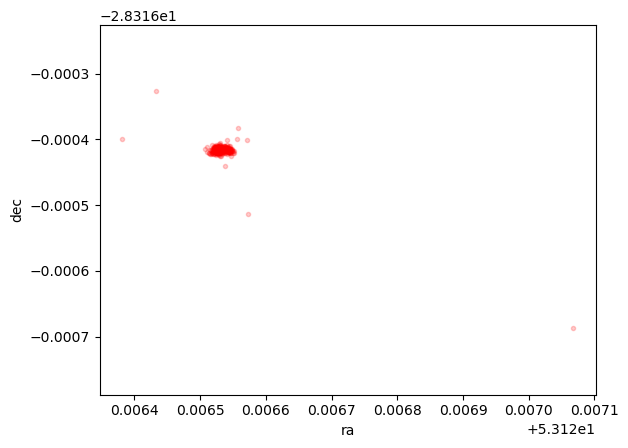

/tmp/ipykernel_6713/3987869202.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


Clipped distribution of points:


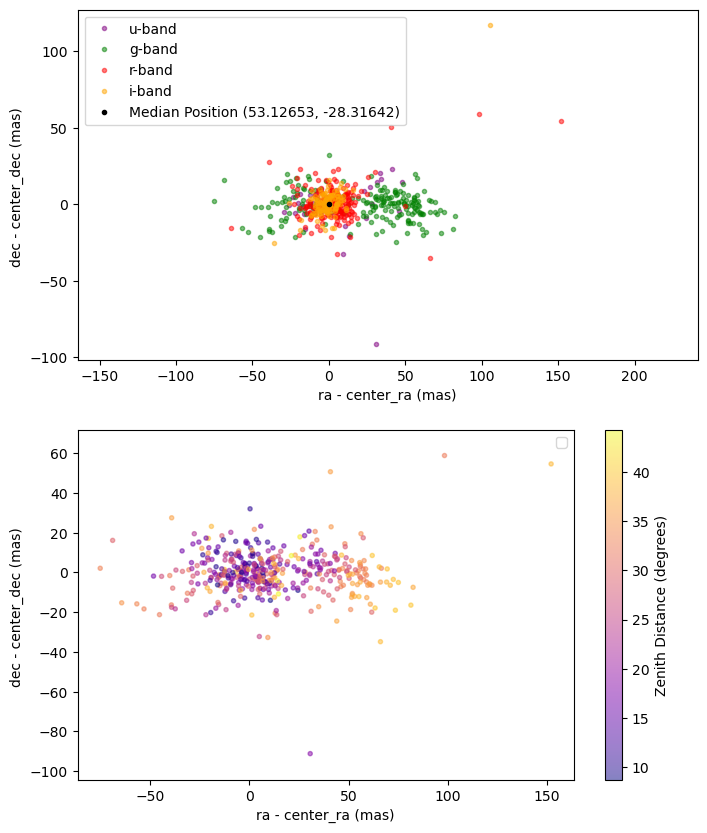

In [15]:
# Plot to check the distribution of visits looks as expected for a single object (limited to a few arcsec)
# If there are outliers, adjust the clipping radius below as needed

# Naive approach: should really do a formal fitting to find the center
center_ra = np.median(master_all['ra'])
center_dec = np.median(master_all['dec'])

print('Median coordinates: ', np.round(center_ra, 8), np.round(center_dec, 8))

plt.plot(master_all['ra'], master_all['dec'], 'r.', alpha = 0.2)
plt.xlabel('ra')
plt.ylabel('dec')
plt.axis('equal')
plt.show()
plt.close()


# create a mask to clip out the outliers:
clipping_radius = 0.0001 # degrees, 0.0001 is ~0.36 arcsec

mask = ((master_all['ra'] - center_ra)**2 + (master_all['dec'] - center_dec)**2) < (clipping_radius)**2
master = master_all[mask]

master_original = master.copy()


# print('Number of points after clipping: ', len(master))
print('Clipped distribution of points:')


scale = 3600 * 1000 #to convert degrees to milliarcseconds for plotting


# Plot the distribution of points, color coded by band and zenith distance
fig, ax = plt.subplots(2,1, figsize=(8, 10))

colors = {'u': 'purple', 'g': 'green', 'r': 'red', 'i': 'orange'}
for band in 'ugri':
    mask = master['band'] == band
    ax[0].plot((master['ra'][mask] - center_ra)*scale, (master['dec'][mask] - center_dec)*scale, '.', alpha = 0.5, label = f'{band}-band', color=colors[band])

# plt.plot(master['ra'], master['dec'], 'r.', alpha = 0.2)
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
ax[0].plot(0, 0, 'k.', label = f"Median Position ({center_ra:.5f}, {center_dec:.5f})")
ax[0].legend()
ax[0].set_xlabel('ra - center_ra (mas)')
ax[0].set_ylabel('dec - center_dec (mas) ')
ax[0].axis('equal')


mask = (master['band'] == 'u') | (master['band'] == 'g') |(master['band'] == 'r')
sc = plt.scatter((master['ra']- center_ra)[mask]*scale, (master['dec'] - center_dec)[mask]*scale, c=master['zenithDistance'][mask], cmap = 'plasma', alpha = 0.5, marker = '.')
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
plt.colorbar(sc, label = 'Zenith Distance (degrees)')
# plt.plot(0, 0, 'k.', label = "Median Position")
ax[1].legend()
ax[1].set_xlabel('ra - center_ra (mas)')
ax[1].set_ylabel('dec - center_dec (mas) ')
ax[1].axis('equal')
plt.show()

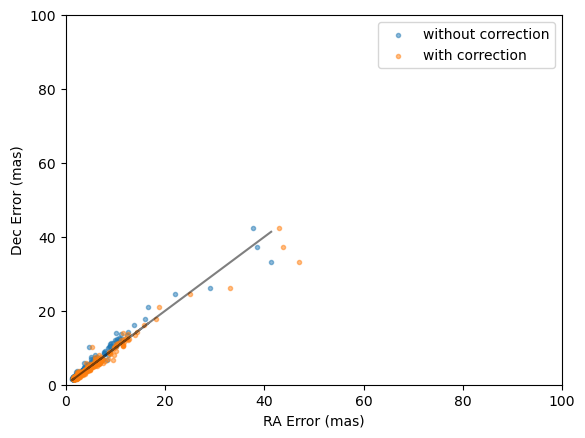

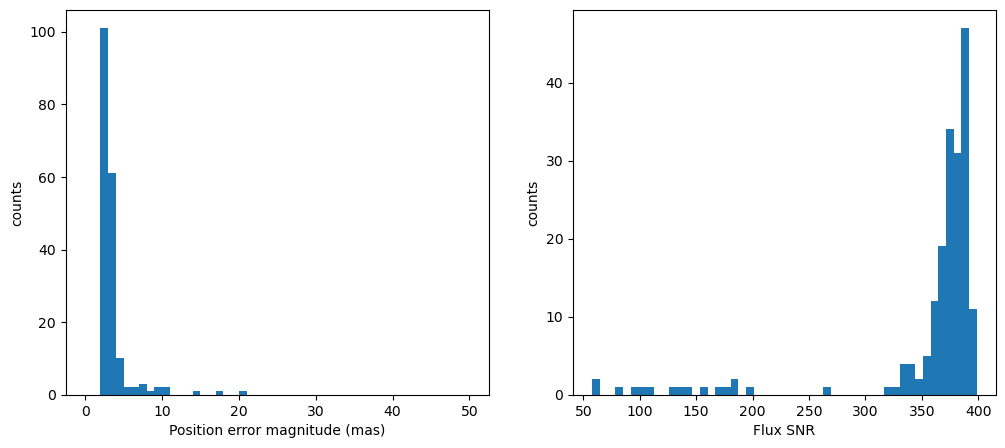

In [16]:
#Apply correction to raErr and ra_dec_Cov to account for overcorrection in DP1 and check data quality
# check distributions of raErr and decErr: (see community forum post for more discussion on this https://community.lsst.org/t/anomalies-in-dp1-right-ascension-errors/11178/13)

correction = np.cos(master_original['dec']*np.pi/180)
plt.scatter(master_original['raErr'] * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.', label = 'without correction')
plt.scatter(master_original['raErr']/correction * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.',
 label = 'with correction')
plt.plot(master_original['raErr'] * 3600 * 10**3, master_original['raErr'] * 3600 * 10**3, 'k-', alpha = 0.5)
plt.xlabel('RA Error (mas)')
plt.ylabel('Dec Error (mas)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()
plt.close()


#apply correction using master_original to prevent overwriting the already corrected values in master:
master['raErr'] = master_original['raErr']/ correction 
master['ra_dec_Cov'] = master_original['ra_dec_Cov']/correction


fig, ax = plt.subplots(1,2, figsize = (12, 5))

band_mask = master['band'] == 'g'

ax[0].hist(np.sqrt(master['raErr'][band_mask]**2 + master['decErr'][band_mask]**2)*3600 * 10**3, 50, range = (0, 50)) # magnitude of position error
ax[0].set_xlabel('Position error magnitude (mas)')
ax[0].set_ylabel('counts')

ax[1].hist(master['psfFlux'][band_mask]/master['psfFluxErr'][band_mask], 50) # magnitude of position error
ax[1].set_xlabel('Flux SNR')
ax[1].set_ylabel('counts')

plt.show()


In [17]:
# Add a few columns to the master table: zenith RA/Dec, parallactic angle, and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction

from utils import add_zenith_coordinates


# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

# Add zenith coordinates to the master table
master = add_zenith_coordinates(master, lat=lat, lon=lon, height=height)

# Add parallactic angle to the master table
from utils import parallactic_angle_from_radec_fast
master = parallactic_angle_from_radec_fast(master, lat=lat, lon=lon, height=height, sidereal_kind = 'mean')


# The following is now redundant and completed in the following cell instead: 
'''

 Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction
# master['q_'] = np.zeros(len(master))

#calculate the delta R (difference in position along the zenith direction) using two different methods as a sanity check 
# method 1 (r_temp) uses the great circle frame transformation in astropy 
# method 2 (r_temp2) uses a simple rotation matrix to rotate the RA/Dec offsets into the parallactic angle frame   
master['r_temp'] = np.zeros(len(master)) 
master['r_temp2'] = np.zeros(len(master))
master['r_err'] = np.zeros(len(master))


# The following should be parallelized for future work
for i in range(len(master)):
    # ra, dec, mjd = master['ra', 'dec', 'expMidptMJD'][i]
    # par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat * u.deg, lon * u.deg, height * u.m)
    # # print(par.value)
    # master['q_'][i] = par.value

    pole = coord.SkyCoord(ra=master['zenith_ra'][i]*u.deg, dec=master['zenith_dec'][i]*u.deg, frame='icrs')
    frame = gc.GreatCircleICRSFrame.from_pole_ra0(pole=pole, ra0=100*u.deg)
    c = coord.SkyCoord(ra=[master['ra'][i], center_ra]*u.deg, dec=[master['dec'][i], center_dec]*u.deg, frame='icrs')
    c_fr = c.transform_to(frame)
    master['r_temp'][i]= (c_fr[0].phi2 -  c_fr[1].phi2).to(u.deg).value

    par = master['q'][i]

    cq, sq = np.cos(par), np.sin(par)
    R = np.array([[cq, -sq], [sq, cq]])
    dRA = (master['ra'][i] - center_ra)*np.cos(master['dec'][i]*np.pi/180) 
    dDec = master['dec'][i] - center_dec
    daz, dalt = R @ np.array([[dRA, dDec]]).T
    master['r_temp2'][i] = dalt
    # master['az_temp'][i] = daz

    # calculate the astrometric uncertainty projected along the zenith direction
    cov_matrix = np.array([[master['raErr'][i]**2, master['ra_dec_Cov'][i]],
                           [master['ra_dec_Cov'][i], master['decErr'][i]**2]])
    r_err_matrix = R @ cov_matrix @ R.T
    master['r_err'][i] = np.sqrt(r_err_matrix[1,1])
    # master['az_err'][i] = np.sqrt(r_err_matrix[0,0])

'''


"\n\n Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction\n# master['q_'] = np.zeros(len(master))\n\n#calculate the delta R (difference in position along the zenith direction) using two different methods as a sanity check \n# method 1 (r_temp) uses the great circle frame transformation in astropy \n# method 2 (r_temp2) uses a simple rotation matrix to rotate the RA/Dec offsets into the parallactic angle frame   \nmaster['r_temp'] = np.zeros(len(master)) \nmaster['r_temp2'] = np.zeros(len(master))\nmaster['r_err'] = np.zeros(len(master))\n\n\n# The following should be parallelized for future work\nfor i in range(len(master)):\n    # ra, dec, mjd = master['ra', 'dec', 'expMidptMJD'][i]\n    # par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat * u.deg, lon * u.deg, height * u.m)\n    # # print(par.value)\n    # master['q_'][i] = par.value\n\n    pole = coord.SkyCoord(ra=master[

/tmp/ipykernel_6713/2353695272.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


--- Naive Fitting Approach:
Center coord:  (np.float64(53.126528712652416), np.float64(-28.316415494393823))
Center err:  (np.float64(2.1957731884238984e-06), np.float64(2.1928525697498414e-06))
u 32.81 +- 2.27
g 66.61 +- 0.32
r 11.88 +- 0.33
i 2.79 +- 0.45
z -5.5 +- 0.76
y -6.7 +- 3.85
--- Complete Fitting Approach:
Center coord:  (np.float64(53.12652915734961), np.float64(-28.31641530278316))
Center err:  (np.float64(1.0190467626406025e-07), np.float64(3.5088756938904526e-07))
u 33.92 +- 7.03
g 65.75 +- 1.14
r 11.3 +- 1.16
i 1.92 +- 1.49
z -7.27 +- 2.43
y -7.27 +- 11.89
1.6009098942504352 0.6897983880094216


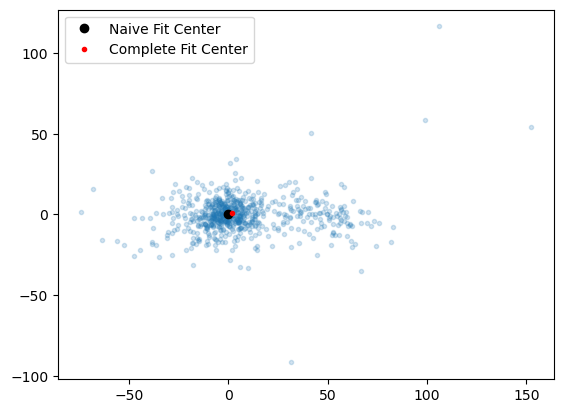

In [18]:
# *** In development ***

# Generate and run a function that takes in the locations of each source and the band,
# and returns the \Delta R_45 for each band AND (optionally) the center location

def compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov):
        # For a trial center, compute projected zenith offset dR and propagated uncertainty dR_err.
        dR = np.zeros(len(ra))
        dR_err = np.zeros(len(ra))

        for i in range(len(ra)):
            # Rotation from RA/Dec offsets into azimuth/altitude frame using parallactic angle q.
            cq, sq = np.cos(par[i]), np.sin(par[i])
            rot = np.array([[cq, -sq], [sq, cq]])

            dRA = (ra[i] - center_ra) * np.cos(dec[i] * np.pi / 180)
            dDec = dec[i] - center_dec
            _, dalt = rot @ np.array([[dRA, dDec]]).T
            dR[i] = dalt

            # Propagate RA/Dec covariance into rotated frame and keep altitude component uncertainty.
            cov_matrix = np.array([[raErr[i]**2, ra_dec_Cov[i]],
                                   [ra_dec_Cov[i], decErr[i]**2]])
            r_err_matrix = rot @ cov_matrix @ rot.T
            dR_err[i] = np.sqrt(np.abs(r_err_matrix[1, 1]))

        # Keep only finite, positive uncertainties for weighted residuals.
        finite_mask = np.isfinite(dR) & np.isfinite(dR_err) & (dR_err > 0)
        return dR, dR_err, finite_mask


def fitDeltaR45_Naive(master, snr_cut=10):
    """Fit per-band R45 using a fixed center estimated from detections.

    Strategy
    --------
    1) Apply SNR cut.
    2) Estimate unrefracted center from median (prefer r/i at low zenith distance).
    3) Compute dR and dR_err for each row.
    4) Fit R45 per band with weighted curve_fit to dR = R45 * tan(z).

    Returns
    -------
    (r45s, r45_errs, center_fit, center_fit_err, n_rows_used)
    """
    if snr_cut is not None:
        snr_mask = master['psfFlux'] / master['psfFluxErr'] >= snr_cut
        master = master[snr_mask]

    if len(master) == 0:
        raise ValueError('No rows available after SNR cut.')

    par = np.array(master['q'])
    ra = np.array(master['ra'])
    dec = np.array(master['dec'])
    ra_err = np.array(master['raErr'])
    dec_err = np.array(master['decErr'])
    ra_dec_cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band'])

    # Same center mask strategy as DCR_in_DP1 naive method
    center_mask = ((band_col == 'r') | (band_col == 'i')) & (zenith_distance < 20)
    if np.sum(center_mask) < 40:  # fallback if there are too few center-defining points
        print('--- Warning!! Too few points to properly estimate center. Using median of all points ---')
        center_mask = np.ones(len(master), dtype=bool)

    center_ra = np.median(ra[center_mask])
    center_dec = np.median(dec[center_mask])
    center_ra_err = np.std(ra[center_mask])
    center_dec_err = np.std(dec[center_mask])

    dR, dR_err, finite_mask = compute_dR_and_err(
        center_ra, center_dec, ra, dec, par, ra_err, dec_err, ra_dec_cov
    )

    def dR_model(z, r45):
        return r45 * np.tan(z * np.pi / 180)

    r45s = {}
    r45_errs = {}

    unique_bands = np.unique(band_col)
    for band in unique_bands:
        band_mask = (band_col == band) & finite_mask
        if np.sum(band_mask) < 2:
            continue

        popt, pcov = curve_fit(
            dR_model,
            zenith_distance[band_mask],
            dR[band_mask],
            sigma=dR_err[band_mask],
            p0=[0],
            absolute_sigma=True,
            maxfev=10000,
        )

        r45s[band] = popt[0]
        r45_errs[band] = np.sqrt(np.diag(pcov))[0]

    return r45s, r45_errs, (center_ra, center_dec), (center_ra_err, center_dec_err), len(master)


def fitDeltaR45_Complete(master_, SNR=10):
    master = master_.copy()
    # Use least-squares for a joint fit of center_ra, center_dec, and per-band R45 values.
    from scipy.optimize import least_squares

    # Optional SNR cut to remove low-quality detections before fitting.
    if SNR is not None:
        SNR_mask = master['psfFlux'] / master['psfFluxErr'] >= SNR
        master = master[SNR_mask]

    # Convert table columns to numpy arrays for fast numeric operations.
    par = np.array(master['q'])
    ra = np.array(master['ra'])
    dec = np.array(master['dec'])
    raErr = np.array(master['raErr'])
    decErr = np.array(master['decErr'])
    ra_dec_Cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band'])

    # Guard against empty input after cuts.
    if len(master) == 0:
        raise ValueError('No rows available after masking.')

    # Initial center guess and prior widths from the sample distribution.
    center_ra0 = np.median(ra)
    center_dec0 = np.median(dec)
    center_ra_err0 = np.std(ra)/np.sqrt(len(ra))
    center_dec_err0 = np.std(dec)/np.sqrt(len(ra))

    # Avoid zero-width priors, which can cause divide-by-zero in residuals.
    if center_ra_err0 <= 0:
        center_ra_err0 = 1e-8
    if center_dec_err0 <= 0:
        center_dec_err0 = 1e-8

    # Build a compact mapping from band labels to parameter indices.
    unique_bands = np.unique(band_col)
    if len(unique_bands) == 0:
        raise ValueError('No valid bands available for fitting.')

    band_to_index = {band: i for i, band in enumerate(unique_bands)}
    band_index = np.array([band_to_index[band] for band in band_col], dtype=int)

    # Compute dR once at the initial center for robust R45 initialization.
    dR0, dR_err0, finite_mask0 = compute_dR_and_err(center_ra0, center_dec0, ra, dec, par, raErr, decErr, ra_dec_Cov)

    def func(z, R45):
        # Per-band DCR model: dR = R45 * tan(z).
        return R45 * np.tan(z * np.pi / 180)

    # Initialize per-band R45 with independent weighted fits at fixed initial center.
    R45_init = np.zeros(len(unique_bands))
    for j, band in enumerate(unique_bands):
        band_mask = (band_col == band) & finite_mask0
        if np.sum(band_mask) < 2:
            R45_init[j] = 0.0
            continue
        try:
            popt, _ = curve_fit(
                func,
                zenith_distance[band_mask],
                dR0[band_mask],
                sigma=dR_err0[band_mask],
                p0=[0],
                absolute_sigma=True,
                maxfev=10000,
            )
            R45_init[j] = popt[0]
        except Exception:
            # Fallback if a single-band initialization fit fails.
            R45_init[j] = 0.0

    # Parameter vector: [center_ra, center_dec, R45_band0, R45_band1, ...].
    x0 = np.concatenate(([center_ra0, center_dec0], R45_init))

    def residuals(params):
        # Unpack trial parameters.
        center_ra = params[0]
        center_dec = params[1]
        R45_vals = params[2:]

        # Data residuals: (measured dR - model dR)/sigma.
        dR, dR_err, finite_mask = compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov)
        model = R45_vals[band_index] * np.tan(zenith_distance * np.pi / 180)
        data_resid = (dR - model) / dR_err
        data_resid = data_resid[finite_mask]

        # Weak Gaussian priors on center coordinates from the initial guess uncertainties.
        prior_resid = np.array([
            (center_ra - center_ra0) / center_ra_err0,
            (center_dec - center_dec0) / center_dec_err0,
        ])

        # Joint residual vector used by least_squares.
        return np.concatenate((data_resid, prior_resid))

    # Solve the joint nonlinear least-squares problem.
    result = least_squares(residuals, x0, method='trf')

    # Extract best-fit parameters.
    best_params = result.x
    center_ra_fit, center_dec_fit = best_params[0], best_params[1]
    R45_fit = best_params[2:]

    # Estimate parameter covariance from Jacobian (scaled by reduced chi^2).
    n_resid = len(result.fun)
    n_param = len(best_params)
    dof = n_resid - n_param

    if dof > 0 and result.jac.size > 0:
        try:
            jacobian = result.jac
            cov = np.linalg.pinv(jacobian.T @ jacobian)
            chi2_red = 2 * result.cost / dof
            cov = cov * chi2_red
            param_err = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
        except Exception:
            param_err = np.full(n_param, np.nan)
    else:
        param_err = np.full(n_param, np.nan)

    # Split uncertainties into center terms and band terms.
    center_ra_fit_err, center_dec_fit_err = param_err[0], param_err[1]
    R45_fit_err = param_err[2:]

    # Repackage outputs to match the format of fitDeltaR45 for easy comparison.
    R45s = {band: R45_fit[j] for j, band in enumerate(unique_bands)}
    R45_errs = {band: R45_fit_err[j] for j, band in enumerate(unique_bands)}

    return R45s, R45_errs, (center_ra_fit, center_dec_fit), (center_ra_fit_err, center_dec_fit_err)


R45s, R45errs, centerest, centererr, N = fitDeltaR45_Naive(master)
print('--- Naive Fitting Approach:')
print('Center coord: ', centerest)
print('Center err: ', centererr)
for key in 'ugrizy':
    try:
        item = R45s[key]
        print(key, np.round(item * 3600 * 10**3, 2), '+-', np.round( R45errs[key] * 3600 * 10**3, 2))
    except:
        continue

R45s2, R45errs2, centerest2, centererr2 = fitDeltaR45_Complete(master)
print('--- Complete Fitting Approach:')
print('Center coord: ', centerest2)
print('Center err: ', centererr2)
for key in 'ugrizy':
    try:
        item = R45s2[key]
        print(key, np.round(item * 3600 * 10**3, 2), '+-', np.round( R45errs2[key] * 3600 * 10**3, 2))
    except:
        continue

plt.scatter((master['ra'] - centerest[0]) * 3600 * 10**3, (master['dec'] - centerest[1]) * 3600 * 10**3, marker = '.', alpha = 0.2)
plt.plot(0,0, 'ko' , label = 'Naive Fit Center')
plt.plot((centerest2[0] - centerest[0]) * 3600 * 10**3, (centerest2[1] - centerest[1])* 3600 * 10**3, 'r.', label = 'Complete Fit Center')
plt.legend()
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
print((centerest2[0] - centerest[0]) * 3600 * 10**3, (centerest2[1] - centerest[1])* 3600 * 10**3)

In [19]:
# Pick a center and calculate the final dR and dR err, add them to the master table

par = np.array(master['q'])
ra = np.array(master['ra'])
dec = np.array(master['dec'])
raErr = np.array(master['raErr'])
decErr = np.array(master['decErr'])
ra_dec_Cov = np.array(master['ra_dec_Cov'])

dR, dR_err, finite_mask = compute_dR_and_err(centerest[0], centerest[1], ra, dec, par, raErr, decErr, ra_dec_Cov)
# centerest[0], centerest[1]

master['dR'] = dR
master['dR_err'] = dR_err


/tmp/ipykernel_6713/2353695272.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


<>:133: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_6713/3565703.py:133: SyntaxWarning: invalid escape sequence '\D'
  print('expected \Delta R_45: ', model_dR[band][-1]*1e3)


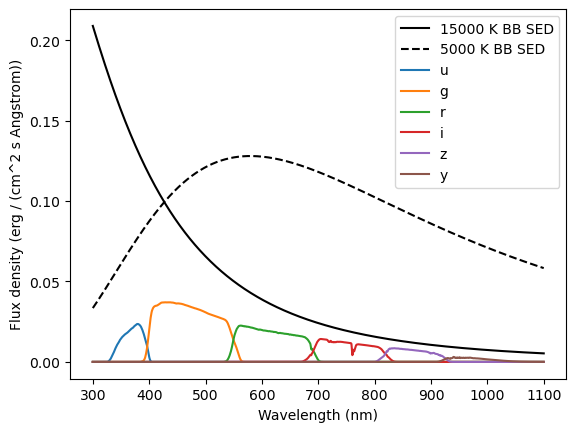

g-r color of source:  -0.2414
0.03285082912566675 0.0032671346150235383
Estimated wavelength for band u: 369.94 nm (+ 0.35 / - 0.35)
expected \Delta R_45:  31.76598613161019
Simulated BB estimated wavelength for band {band}:  370.06  nm


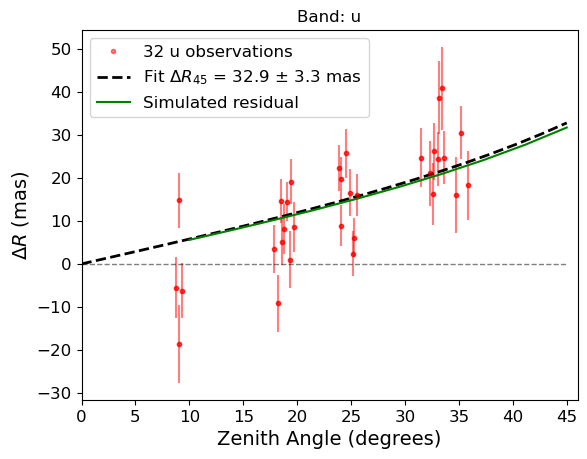

0.06669016047715177 0.0013630782513522443
Estimated wavelength for band g: 470.04 nm (+ 0.32 / - 0.32)
expected \Delta R_45:  54.45289414855381
Simulated BB estimated wavelength for band {band}:  472.95  nm


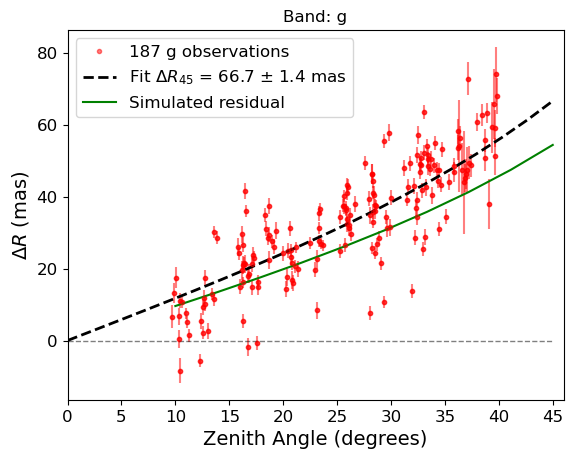

0.011901481679195082 0.0009899710977789118
Estimated wavelength for band r: 616.15 nm (+ 0.53 / - 0.53)
expected \Delta R_45:  13.636196234031672
Simulated BB estimated wavelength for band {band}:  615.23  nm


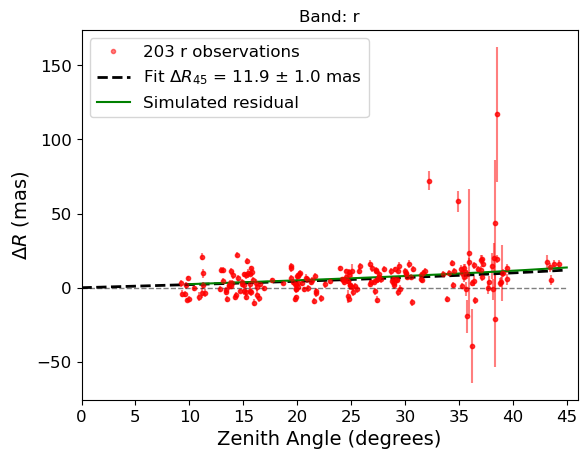

0.0027945469322236717 0.0012564093761864477
Estimated wavelength for band i: 751.8 nm (+ 1.23 / - 1.22)
expected \Delta R_45:  4.30046604378731
Simulated BB estimated wavelength for band {band}:  750.34  nm


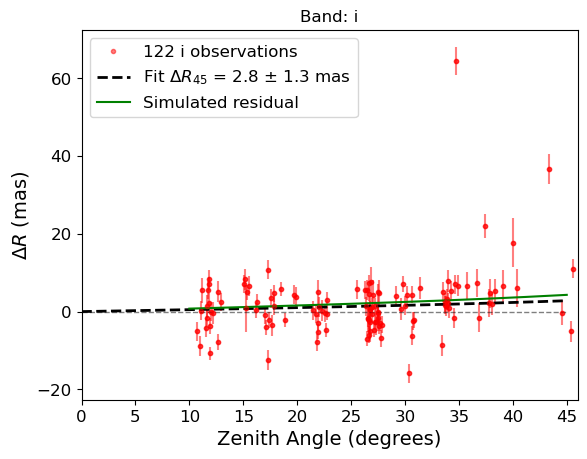

-0.005507023388114706 0.0013803483349476677
Estimated wavelength for band z: 875.1 nm (+ 2.16 / - 2.14)
expected \Delta R_45:  1.3298087842841255
Simulated BB estimated wavelength for band {band}:  864.73  nm


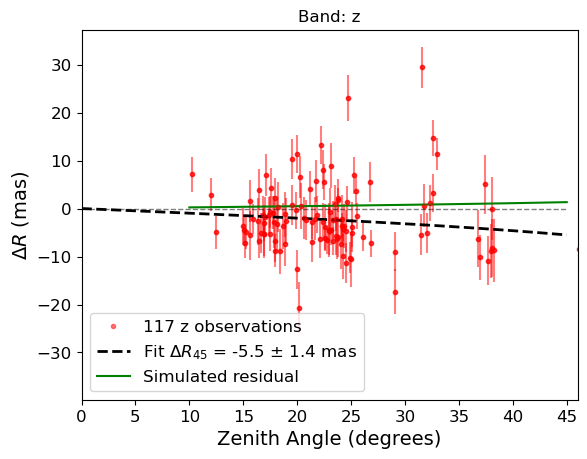

-0.006712760715190789 0.004276807022078407
Estimated wavelength for band y: 988.15 nm (+ 9.62 / - 9.26)
expected \Delta R_45:  0.8642901957145455
Simulated BB estimated wavelength for band {band}:  971.98  nm


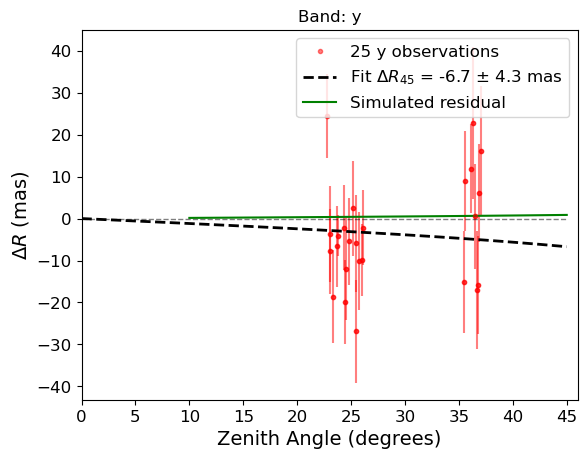

In [20]:
# Generate a model of the expected DCR for black bodys (if the temperatures are approximately known)
# The model uses a blackbody SED of a specified temperature as the source, and a second blackbody SED of a different temperature as the reference
# Plot the residuals in each band with a best-fit model and the expected model


from astropy.modeling.models import BlackBody
from astropy.constants import c
import astropy.units as u
from utils import BB, apply_filter
from utils import apply_DCR, weighted_avg_and_std


def dR_model(z, c):
    return c * np.tan(z * np.pi/180)


# Define the source and reference temperatures:
source_temperature = 15000 #K
reference_temperature = 5000 #K


wavelengths = np.linspace(300, 1100, 1000) # nm 


BBsrc = BB(wavelengths, source_temperature, 1e-9) # flam units
BBref = BB(wavelengths, reference_temperature, 1e-7) # flam units

seds = [BBsrc, BBref,  np.ones(len(wavelengths))*np.max(BBsrc)*0.1]

# Plot the model SEDs
plt.plot(wavelengths, BBsrc, 'k-', label = f'{source_temperature} K BB SED')
plt.plot(wavelengths, BBref, 'k--', label = f'{reference_temperature} K BB SED')

# WARNING: this code leaves SEDs in units of flux density (flam) 
# when it should be in photon density for finding the true mean and variance

filtered_bb = {}
Flux = {}

for band in 'ugrizy':
    filtered_bb[band]= apply_filter(wavelengths , seds, band) # apply filter takes wavelengths in nm
    # Flux[band] = integrate.simpson(y = filtered_bb[band][0],x =  wavelengths)
    Flux[band] = synth_fnu(wavelengths, BBsrc, band, wl_units = 'nm')
    plt.plot(wavelengths, filtered_bb[band][0], label = f'{band}') # flux: {np.round(Flux[band], 4)}')

plt.legend()
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux density (erg / (cm^2 s Angstrom))')
plt.show()
plt.close()

gr_color = -2.5 * np.log10(Flux['g'] / Flux['r'])
print('g-r color of source: ', np.round(gr_color, 4))


# Calculate the DCR effect for a range of zenith angles

zeniths = np.linspace(10, 45, 10) #degrees

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067


model_dR = {}
for band in 'ugrizy':
    model_dR[band] = np.array([])

model_stdevs = {}
for band in 'ugrizy':
    model_stdevs[band] = np.array([])

for zenith in zeniths:

    
    # convert flux density to photon density
    h  = 6.62607015e-27       # erg s
    c  = 2.99792458e17        # nm / s
    hc = h * c                # erg nm (≈ 1.986e-9)
    filtered_bb_photd = {band: filtered_bb[band] * wavelengths / hc for band in filtered_bb}

    refraction_angles, filtered_refracted_data = apply_DCR(wavelengths, filtered_bb_photd, zenith, pressure, temperature, H2O_pressure)


    means, stdevs = weighted_avg_and_std(refraction_angles, filtered_refracted_data, multi = True)

    for band in 'ugrizy':
        model_dR[band] = np.append(model_dR[band], means[band][0] - means[band][1]) #difference between source and reference SEDs
        model_stdevs[band] = np.append(model_stdevs[band], stdevs[band][0]) #just the source SED stdev



from wavelength_estimate import generate_templates, estimate_mean_wave
templates = generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False)



# Plot the model results on top of the data

for band in 'ugrizy':
    band_mask = master['band'] == band


    #add another band mask to throw out large errors
    error_mask = master['dR_err']<  100 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask


    if np.sum(band_mask) > 0:

        
        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanz = np.tan(z * np.pi/180)

        dR = master['dR'][band_mask] #master['r_temp'][band_mask]
        dR_err =master['dR_err'][band_mask] #master['r_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        print(popt[0]*3600, perr[0]*3600)

        wave_max, wave_mean, wave_min = estimate_mean_wave(np.array([popt[0] - perr[0], popt[0], popt[0] + perr[0]])*3600, band, *templates)
        print(f'Estimated wavelength for band {band}: {np.round(wave_mean, 2)} nm (+ {np.round(wave_max - wave_mean, 2)} / - {np.round(wave_mean - wave_min, 2)})')
        # print('BB estimated wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][0], 2)/10, ' nm')
        # print('BB reference wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][1], 2)/10, ' nm')
        print('expected \Delta R_45: ', model_dR[band][-1]*1e3)
        wave_sim = estimate_mean_wave(np.array([model_dR[band][-1]]), band, *templates)[0]
        print('Simulated BB estimated wavelength for band {band}: ', np.round(wave_sim, 2), ' nm')


        plt.plot(z, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} {band} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
        plt.errorbar(z, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        
        z_temp = np.linspace(0, 45, 20) 
        tanz_temp = np.tan(z_temp * np.pi/180)
        plt.plot(z_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit $\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 1)} $\pm$ {np.round(perr[0]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        plt.plot(zeniths, model_dR[band] * 10**3 , 'g-', label = f'Simulated residual') #{source_temperature} K star (reference: {reference_temperature} K star)')
        
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle (degrees)', fontsize = 14)
        plt.ylabel(r'$\Delta R$ (mas)', fontsize = 14)
        plt.legend(fontsize = 12)
        plt.xlim(0, 46)
        # plt.xlim(0, 1.1)
        plt.tick_params(axis='both', which='major', labelsize=12)
        
        plt.xticks([0, 5, 10,15, 20, 25, 30, 35, 40, 45])

        # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

        plt.show()
        plt.close()


0.03285082912566675 0.0032671346150235383


<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_6713/2501595877.py:53: SyntaxWarning: invalid escape sequence '\D'
  ax[i].plot(zeniths_, model_dR[band] * 10**3 , 'g-', label = f'Expected: $\Delta R_{{45}}$ = {np.round(model_dR[band][-1]*1e3, 1)} mas') #{source_temperature} K star (reference: {reference_temperature} K star)')


0.066689926299367 0.0013708199360041445


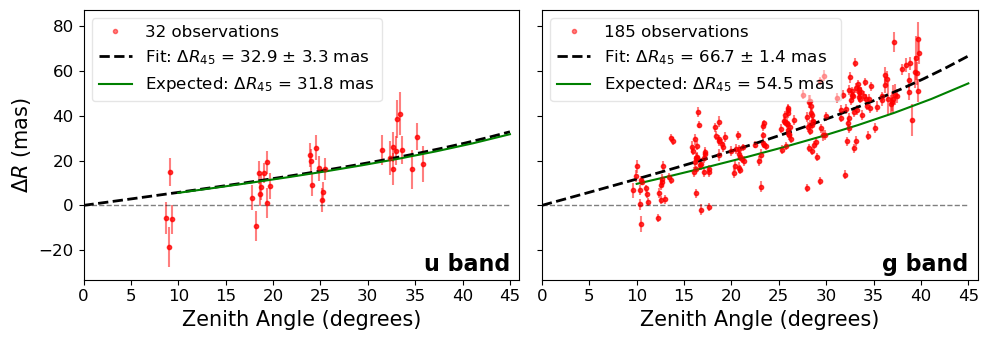

In [21]:
# Plot in a grid for publishing 


def plotGrid(band_, r_, r_err_, airmass_, savefigloc = None):
    

    def dR_model2(z, R, c):
        return R * np.tan(z * np.pi/180) + c

    fig, ax = plt.subplots(1, 2, figsize=(10,3.5), sharey = 'row', sharex = True)

    for i, band in enumerate('ug'):
        # band_mask = master['band'] == band
        band_mask = band_ == band

        #add another band mask to throw out large errors
        # error_mask = master['r_err']<  200 / ( 3600 * 10**3)# degrees
        error_mask = r_err_ <  10 / ( 3600 * 10**3)# degrees
        band_mask = band_mask & error_mask
        

        if np.sum(band_mask) > 0:
            
            # airmass = master[band_mask]['airmass']
            airmass = airmass_[band_mask]
            z = np.arccos(1 / airmass) * 180 / np.pi

            z_ = z #np.tan(z * np.pi/180) #fit in tan(z) space since that is the expected functional form of the DCR effect
            zeniths_ = zeniths #np.tan(zeniths * np.pi/180)
            
            # dR = master['r_temp'][band_mask]
            # dR_err = master['r_err'][band_mask]
            dR = r_[band_mask]
            dR_err = r_err_[band_mask]

            popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0 / (3600 * 10**3)]) #, 0])
            perr = np.sqrt(np.diag(pcov))
            print(popt[0]*3600, perr[0]*3600)

            # n = i // 2
            # m = i % 2



            ax[i].plot(z_, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
            ax[i].errorbar(z_, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
            z_temp = np.linspace(0, 45, 20) 
            z_temp_ = z_temp #np.tan(z_temp * np.pi/180)

            ax[i].plot(z_temp_, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit: $\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 1)} $\pm$ {np.round(perr[0]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
            # ax[i].plot(z_temp_, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit: Intercept = {np.round(popt[1]*3600*1000, 1)} $\pm$ {np.round(perr[1]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
            ax[i].plot(z_temp_, np.zeros(len(z_temp_)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
            ax[i].plot(zeniths_, model_dR[band] * 10**3 , 'g-', label = f'Expected: $\Delta R_{{45}}$ = {np.round(model_dR[band][-1]*1e3, 1)} mas') #{source_temperature} K star (reference: {reference_temperature} K star)')
            # ax[i].set_title(f'Band: {band}', fontsize = 16)
            # ax[i].set_xlabel('Zenith Angle (Degrees)', fontsize = 12)
            # ax[i].set_ylabel(r'$\Delta R$ (mas)', fontsize = 12)
            ax[i].set_xlim(0, 46)
            ax[i].legend(loc = 'upper left',fontsize = 12, framealpha = 0.5)
            ax[i].tick_params(axis='both', which='major', labelsize=12)
            ax[i].set_xticks([0, 5, 10,15, 20, 25, 30, 35, 40, 45])

            # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

            # plt.show()
            # plt.close()

    fig.subplots_adjust(wspace=0) 
    
    ax[0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    # ax[1,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    ax[0].set_xlabel('Zenith Angle (degrees)', fontsize = 15)
    ax[1].set_xlabel('Zenith Angle (degrees)', fontsize = 15)
    
    # ax[0,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    # ax[1,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    # ax[1,0].set_xlabel('tan(Z)', fontsize = 15)
    # ax[1,1].set_xlabel('tan(Z)', fontsize = 15)
    plt.tight_layout()

    ax[0].text(0.78, 1 - 0.9, 'u band', transform=ax[0].transAxes, fontsize=16, fontweight='bold', va='top')
    ax[1].text(0.78, 1 - 0.9, 'g band', transform=ax[1].transAxes, fontsize=16, fontweight='bold', va='top')
    
    # ax[0,0].text(0.78, 1 - 0.9, 'u band', transform=ax[0,0].transAxes, fontsize=16, fontweight='bold', va='top')
    # ax[0,1].text(0.78, 1 - 0.9, 'g band', transform=ax[0,1].transAxes, fontsize=16, fontweight='bold', va='top')
    # ax[1,0].text(0.78, 1 - 0.9, 'r band', transform=ax[1,0].transAxes, fontsize=16, fontweight='bold', va='top')
    # ax[1,1].text(0.78, 1 - 0.9, 'i band', transform=ax[1,1].transAxes, fontsize=16, fontweight='bold', va='top')

    

    if savefigloc is not None:
      fig.savefig(savefigloc)

# plotGrid(master['band'], master['r_temp'], master['r_err'], master['airmass'])


plotGrid(master['band'], master['dR'], master['dR_err'], master['airmass']) #, savefigloc = 'scrap/SiemannPropFigure.pdf')
# plotGrid(master['band'], master['r_temp'], master['r_err'], master['airmass'])

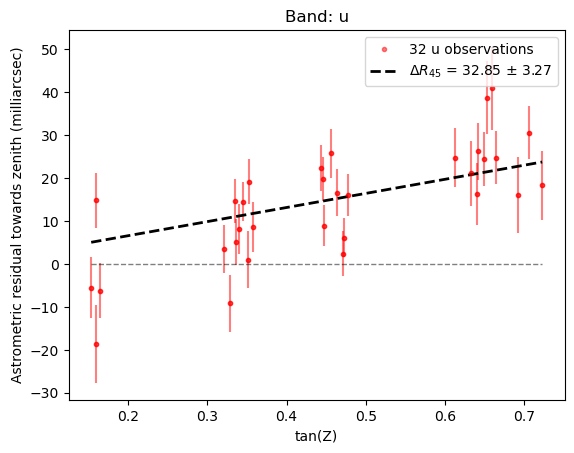

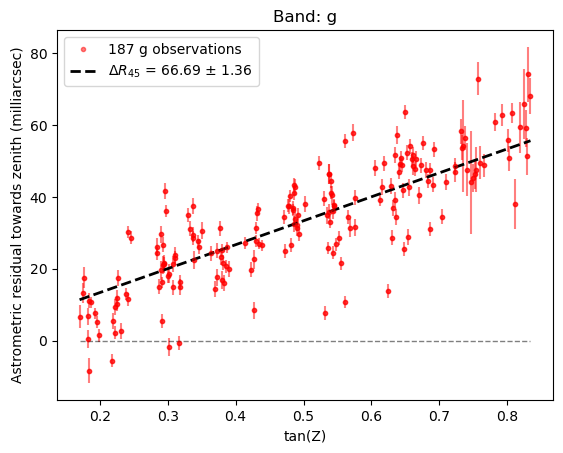

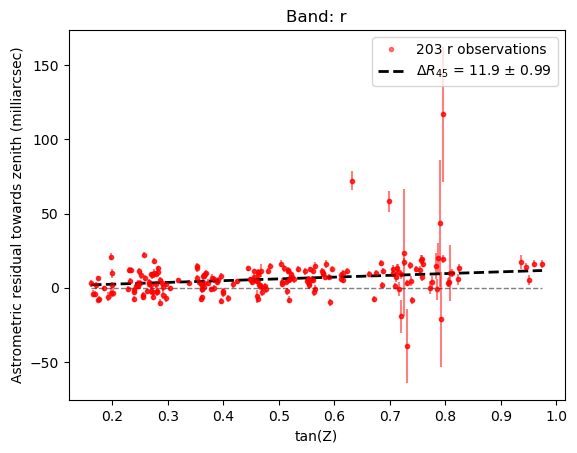

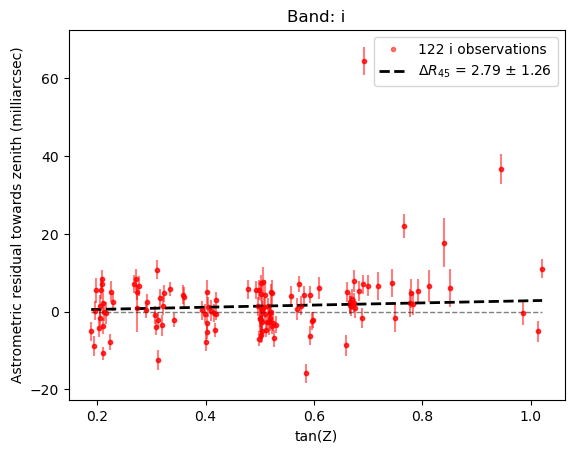

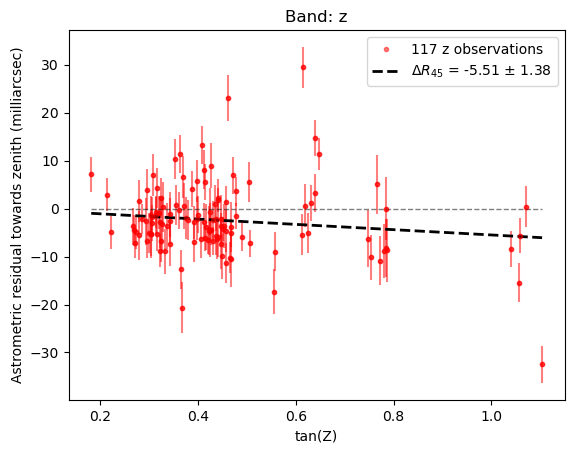

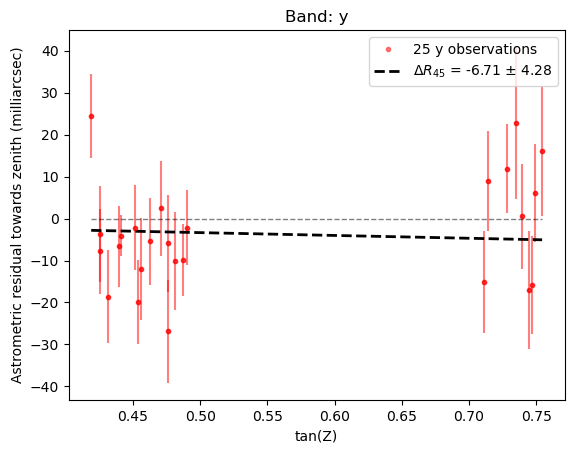

In [22]:
# Plot the residuals along the zenith direction vs zenith angle, for each band
# Also plot a trendline of the form A*tan(z)

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

for band in 'ugrizy':
    band_mask = master['band'] == band

    #Optional: add another mask to throw out large errors
    error_mask = master['dR_err'] <  50 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask

    if np.sum(band_mask) > 0:

        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanZ = np.tan(z * np.pi/180)
        
        dR = master['dR'][band_mask]
        dR_err = master['dR_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        
        #plot dR in milliarcsec as a function of tan(zenith angle)
        plt.plot(tanZ, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} {band} observations')
        plt.errorbar(tanZ, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        
        #plot a trendline
        z_temp = np.linspace(min(z), max(z), 20) 
        tanZ_temp = np.tan(z_temp * np.pi/180)
        plt.plot(tanZ_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'$\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 2)} $\pm$ {np.round(perr[0]*3600*1000, 2)}') #label = 'Trendline: A tan(z)')

        plt.plot(tanZ_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        
        plt.title(f'Band: {band}')
        plt.xlabel('tan(Z)')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()
        plt.show()
        plt.close()

